<a href="https://colab.research.google.com/github/DHRUVCHARNE/Sliding-Window-Counter/blob/main/Sliding_Window_Counter_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

153904 request success
153904 request success
153904 request success
153904 request success153904 request success
153904 request success

153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success153904 request success

153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 request success
153904 requ

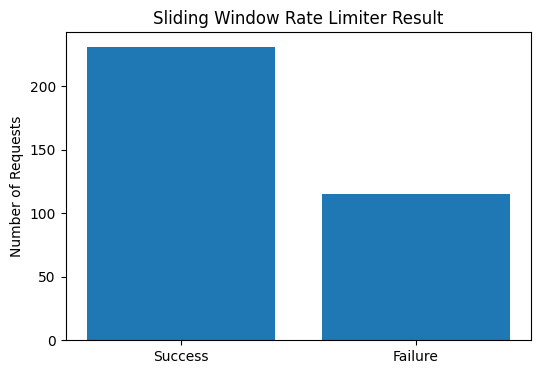

In [77]:
from datetime import datetime
from threading import Thread, Lock
from collections import Counter
from math import floor
import time
import matplotlib.pyplot as plt

counter = Counter()
LIMIT = 100
REQUEST_PER_SEC = 50
lock = Lock()
running = True
results_log = []

WINDOW_SIZE = 1  # seconds


def get_window_key(ts):
    return int(ts.timestamp())  # second-level bucket


def cleanup_expired(now_key):
    # Keep only current and previous window
    keys_to_delete = [k for k in counter if k < now_key - 1]
    for k in keys_to_delete:
        del counter[k]


def process():
    current_time = datetime.now()
    now_key = get_window_key(current_time)
    prev_key = now_key - 1

    # fraction of current second passed
    overlap_ratio = current_time.microsecond / 1_000_000

    with lock:
        cleanup_expired(now_key)

        request_count = floor(
            counter[prev_key] * (1 - overlap_ratio)
            + counter[now_key]
        )

        if request_count >= LIMIT:
            return False

        counter[now_key] += 1

    return True


def request_in_sec(duration_sec=2):
    global running
    start = time.time()

    while time.time() - start < duration_sec:
        time.sleep(1 / REQUEST_PER_SEC)
        res = process()
        results_log.append(res)

    running = False


# Run thread
request_thread = Thread(target=request_in_sec, args=(7,))
request_thread.start()
request_thread.join()

# Plot results
from collections import Counter as C

outcome_counts = C(results_log)
successes = outcome_counts[True]
failures = outcome_counts[False]

labels = ['Success', 'Failure']
counts = [successes, failures]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts)
plt.ylabel('Number of Requests')
plt.title('Sliding Window Rate Limiter Result')
plt.show()